# FOCUS PIP Distributions

Plots PIP distributions for selected GTEx tissues (39-tissue panel) and OneK1K cell types (17-CT panel).

- 2 panel-figures patterned after `sample.png` (one per panel), one for tissues and one for CTs.
- 2 PIP distribution histograms covering ALL gene-tissue / gene-CT pairs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams['font.family'] = 'DejaVu Sans'

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
tissue_df = pd.read_csv('data/focus_credset_gene_tissue_39.tsv', sep='\t')
ct_df     = pd.read_csv('data/focus_credset_gene_tissue_17CT.tsv', sep='\t')

for d in (tissue_df, ct_df):
    d['pips_pop1'] = pd.to_numeric(d['pips_pop1'], errors='coerce')
    d.dropna(subset=['pips_pop1', 'tissues', 'symbol'], inplace=True)

print('Tissue rows:', len(tissue_df), '— tissues:', tissue_df['tissues'].nunique())
print('CT rows    :', len(ct_df),     '— CTs    :', ct_df['tissues'].nunique())

Tissue rows: 17687 — tissues: 39
CT rows    : 1065 — CTs    : 17


In [3]:
# Selected subsets (data files use lowercase; map user-friendly labels for display)
selected_tissues = [
    'thyroid',
    'esophagus_mucosa',
    'heart_atrial_appendage',
    'adipose_subcutaneous',
    'colon_transverse',
    'artery_coronary',
]

selected_cts = [
    'nk',
    'cd4_tcm',
    'cd4_naive',
    'nk_cd56bright',
    'cd4_ctl',
    'treg',
]

def pretty(name):
    return name.replace('_', ' ').title()

# PIP bins for stacked proportion plot
PIP_BINS   = [0.0, 0.1, 0.3, 0.5, 0.8, 1.0]
PIP_LABELS = ['0-0.1', '0.1-0.3', '0.3-0.5', '0.5-0.8', '0.8-1.0']
PIP_COLORS = ['#F0E442', '#56B4E9', '#009E73', '#E69F00', '#D55E00']  # colorblind-friendly

PIP_HIGH_THRESHOLD = 0.1  # for the left frequency bar plot

In [ ]:
def sample_style_panels(df, selected, x_label, suptitle, save_path):
    """Horizontal stacked-proportion bars (one row per group), patterned after sample.png.
       Rows ordered by descending frequency of PIP > threshold (largest on top).
       The 'PIP > thr / N=...' annotation is right-aligned in a fixed column just
       outside the bars; the PIP-bin legend sits at the top-left, by the panel title.
    """
    sub = df[df['tissues'].isin(selected)].copy()

    # Counts above PIP threshold (used to ORDER rows + annotate)
    high = sub[sub['pips_pop1'] > PIP_HIGH_THRESHOLD]
    counts = high['tissues'].value_counts()
    counts = counts.reindex(selected, fill_value=0).sort_values(ascending=False)
    order  = counts.index.tolist()

    # Proportions of each PIP bin per group (same row order)
    sub['pip_bin'] = pd.cut(sub['pips_pop1'], bins=PIP_BINS, labels=PIP_LABELS,
                            include_lowest=True, right=True)
    bin_counts = (sub.groupby(['tissues', 'pip_bin'], observed=False)
                     .size().unstack(fill_value=0)
                     .reindex(index=order, columns=PIP_LABELS, fill_value=0))
    totals = bin_counts.sum(axis=1).replace(0, np.nan)
    props  = bin_counts.div(totals, axis=0).fillna(0)

    fig, ax = plt.subplots(figsize=(9, 4.6))

    y    = np.arange(len(order))
    left = np.zeros(len(order))
    for label, color in zip(PIP_LABELS, PIP_COLORS):
        ax.barh(y, props[label].values, left=left, color=color,
                label=f'PIP {label}', edgecolor='white', linewidth=0.7)
        left += props[label].values

    # Right-margin annotation, aligned in a fixed column just outside the bars.
    # Uses the y-axis transform so x is in axes fraction (>1 = right of plot),
    # y in data coords -> every "PIP > thr" label lines up in one column.
    x_text = 1.03
    for yi, cnt in zip(y, counts.values):
        ax.text(x_text, yi, f'PIP > {PIP_HIGH_THRESHOLD}\nN={int(cnt)}',
                ha='left', va='center', fontsize=9,
                transform=ax.get_yaxis_transform())

    ax.set_yticks(y)
    ax.set_yticklabels([pretty(t) for t in order], fontsize=11)
    ax.invert_yaxis()  # largest N on top
    ax.set_xlim(0, 1.0)
    ax.set_xticks(np.arange(0, 1.01, 0.25))
    ax.set_xlabel('Proportion of gene-pair entries', fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

    # Legend top-left (by the panel title), horizontal strip above the bars
    ax.legend(loc='lower left', bbox_to_anchor=(0.0, 1.005), ncol=5,
              fontsize=8.5, frameon=False, handlelength=1.1,
              columnspacing=1.1, handletextpad=0.4, borderaxespad=0.0)

    ax.set_title(suptitle, fontsize=14, fontweight='bold', pad=30)

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return counts, props


## Sample-style panels — selected tissues (GTEx, 39-tissue panel)

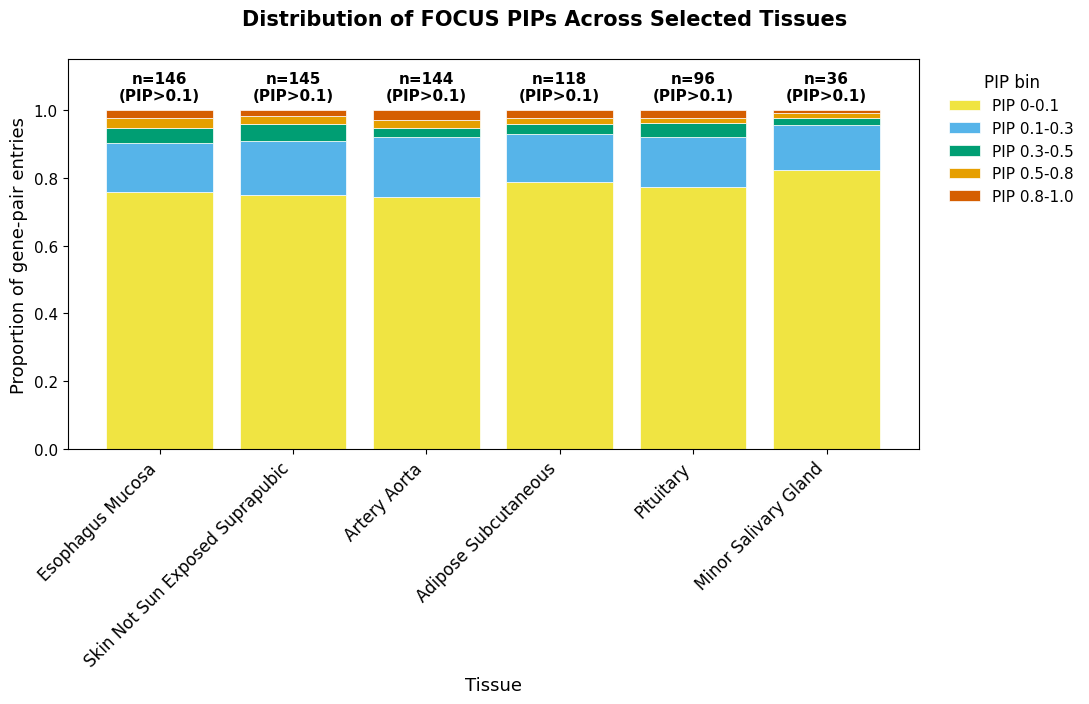

tissues
esophagus_mucosa                   146
skin_not_sun_exposed_suprapubic    145
artery_aorta                       144
adipose_subcutaneous               118
pituitary                           96
minor_salivary_gland                36
Name: count, dtype: int64

In [5]:
tissue_counts, tissue_props = sample_style_panels(
    tissue_df, selected_tissues,
    x_label='Tissue',
    suptitle='Distribution of FOCUS PIPs Across Selected Tissues',
    save_path='figures/focus_pip_tissue_panels.png',
)
tissue_counts

## Sample-style panels — selected cell types (OneK1K, 17-CT panel)

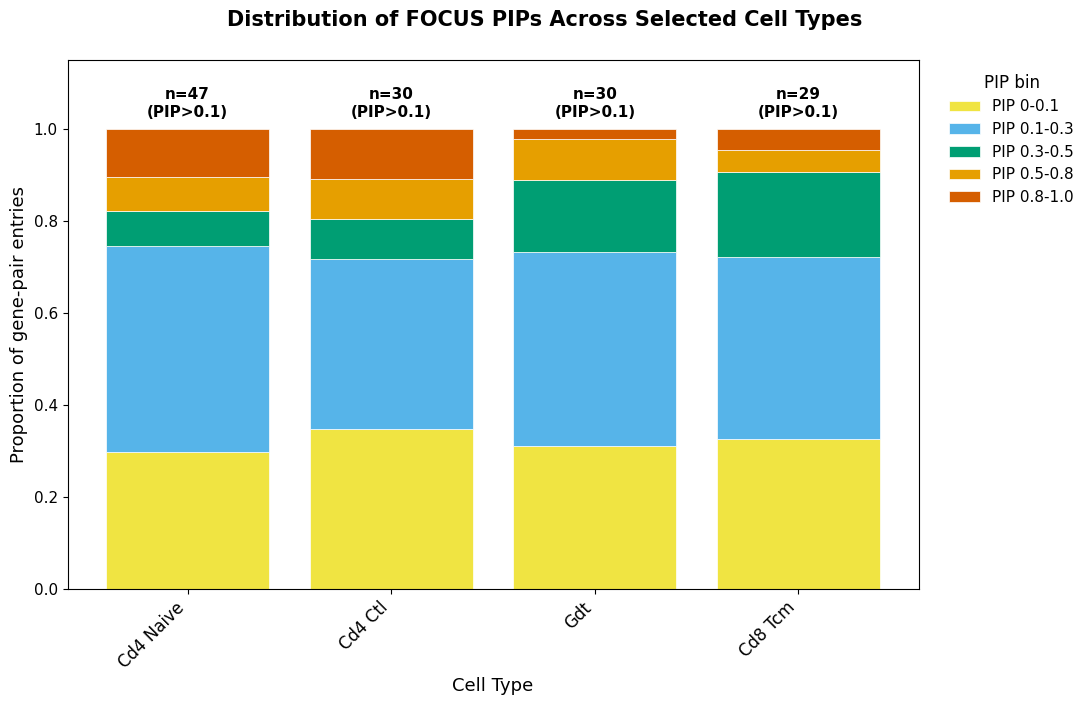

tissues
cd4_naive    47
cd4_ctl      30
gdt          30
cd8_tcm      29
Name: count, dtype: int64

In [6]:
ct_counts, ct_props = sample_style_panels(
    ct_df, selected_cts,
    x_label='Cell Type',
    suptitle='Distribution of FOCUS PIPs Across Selected Cell Types',
    save_path='figures/focus_pip_celltype_panels.png',
)
ct_counts

## PIP distribution — all gene-tissue and all gene-CT pairs

In [7]:
def pip_distribution_combined(tissue_df, ct_df, save_path):
    """Percentage-of-entries histogram with bin width 0.1, both panels overlaid on a single y-axis.
    """
    tissue_pips = tissue_df['pips_pop1'].values
    ct_pips     = ct_df['pips_pop1'].values

    edges  = np.arange(0, 1.01, 0.1)
    labels = [f'{edges[i]:.1f}-{edges[i+1]:.1f}' for i in range(len(edges) - 1)]

    t_counts, _ = np.histogram(tissue_pips, bins=edges)
    c_counts, _ = np.histogram(ct_pips,     bins=edges)
    t_pct = t_counts / t_counts.sum() * 100
    c_pct = c_counts / c_counts.sum() * 100

    fig, ax = plt.subplots(figsize=(10, 8))
    x = np.arange(len(labels))
    bar_w = 0.85

    ax.bar(x, t_pct, width=bar_w, color='#0072B2', edgecolor='black',
           alpha=0.55, label=f'Gene-Tissue (n = {len(tissue_pips):,})', zorder=1)
    ax.bar(x, c_pct, width=bar_w, color='#D55E00', edgecolor='black',
           alpha=0.75, label=f'Gene-Cell Type (n = {len(ct_pips):,})', zorder=3)

    for xi, pt, pc in zip(x, t_pct, c_pct):
        ax.text(xi - 0.18, pt + 0.8, f'{pt:.1f}%', color='#0072B2',
                ha='center', va='bottom', fontsize=14)
        ax.text(xi + 0.18, pc + 0.8, f'{pc:.1f}%', color='#D55E00',
                ha='center', va='bottom', fontsize=14)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=18)
    ax.set_xlabel('PIP bin', fontsize=22)
    ax.set_ylabel('Percentage of entries within panel (%)', fontsize=20)
    ax.set_ylim(0, max(t_pct.max(), c_pct.max()) * 1.30)
    ax.tick_params(axis='y', labelsize=18)
    ax.grid(axis='y', alpha=0.3)

    ax.legend(loc='upper right', fontsize=18, frameon=True)

    def stats(arr, name):
        return (f'{name}: n={len(arr):,}, median={np.median(arr):.3f}\n'
                f'  PIP>0.1: {(arr>0.1).sum():,} ({(arr>0.1).mean()*100:.1f}%)')
    stat_text = stats(tissue_pips, 'Tissues') + '\n' + stats(ct_pips, 'CTs')
    ax.text(0.97, 0.72, stat_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=13,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      edgecolor='black', alpha=0.9))

    ax.set_title('PIP Distribution per Bin', fontsize=22, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


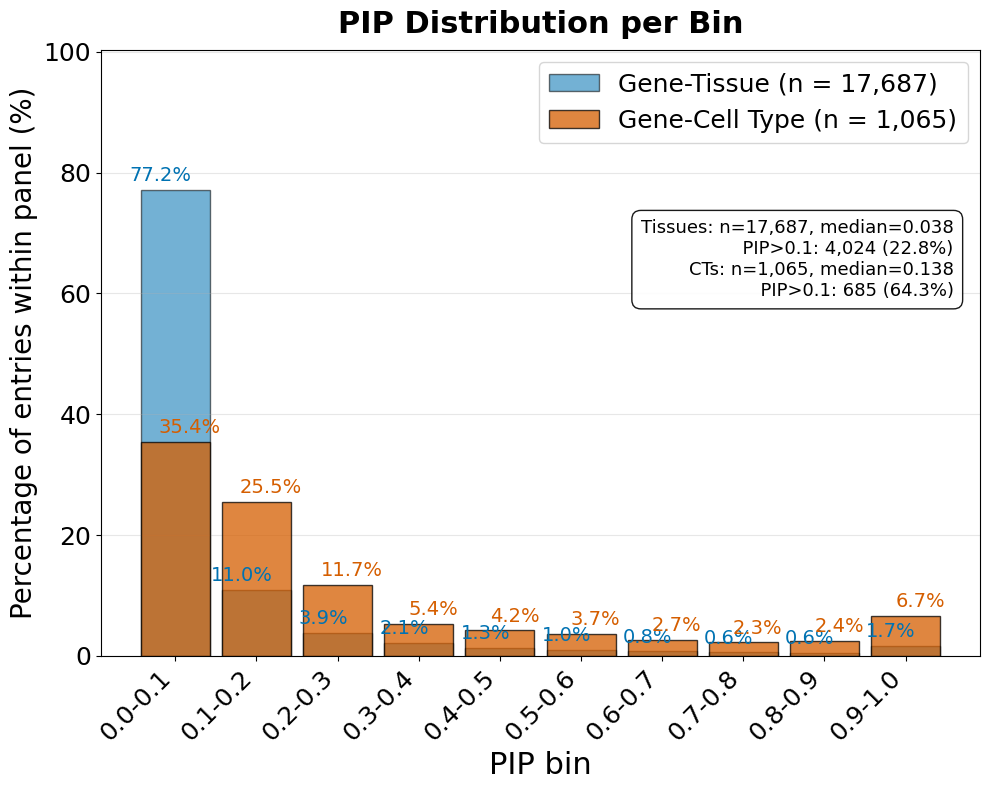

In [8]:
pip_distribution_combined(
    tissue_df, ct_df,
    save_path='figures/focus_pip_distribution_combined.png',
)

## Gene annotation: ENSG -> HGNC symbol

In [9]:
# Load GTEx v8 gene annotation (chr, start, end, gene_name, ?, strand, ensembl_versioned, biotype, ...)
ann = pd.read_csv('data/gene_annotation.txt.gz', sep='\t', header=None, usecols=[3, 6],
                  names=['gene_name', 'ensembl_versioned'], compression='gzip')
# strip ENSG version suffix (e.g. ENSG00000223972.5 -> ENSG00000223972)
ann['ensembl_id'] = ann['ensembl_versioned'].str.split('.').str[0]
ensg_to_symbol = dict(zip(ann['ensembl_id'], ann['gene_name']))
print(f'Loaded {len(ensg_to_symbol):,} ENSG -> symbol mappings')

Loaded 56,156 ENSG -> symbol mappings


## Top 500 genes by PIP (CT panel)

In [10]:
# Top 500 unique genes by max PIP across cell types.
ct_ranked = (ct_df.sort_values('pips_pop1', ascending=False)
                  .drop_duplicates(subset='symbol', keep='first')
                  .reset_index(drop=True))

top500_ct = ct_ranked.head(500)[
    ['symbol', 'tissues', 'pips_pop1',
     'twas_z_pop1', 'chrom', 'tx_start', 'tx_stop', 'block']
].rename(columns={'symbol': 'ensembl_id',
                  'tissues': 'top_cell_type',
                  'pips_pop1': 'max_pip'})
top500_ct.insert(0, 'gene_name', top500_ct['ensembl_id'].map(ensg_to_symbol))

top500_ct.to_csv('outputs/top500_genes_by_pip_CT.csv', index=False)
print(f'Saved {len(top500_ct)} genes -> top500_genes_by_pip_CT.csv')
print(f'PIP range: {top500_ct["max_pip"].min():.4f} - {top500_ct["max_pip"].max():.4f}')
print(f'Genes without HGNC mapping: {top500_ct["gene_name"].isna().sum()}')
print(f'Cell-type counts in top-500:')
print(top500_ct['top_cell_type'].value_counts())
top500_ct.head(20)

Saved 500 genes -> top500_genes_by_pip_CT.csv
PIP range: 0.1160 - 1.0000
Genes without HGNC mapping: 0
Cell-type counts in top-500:
top_cell_type
cd16_mono         55
nk                51
cd4_tcm           44
cd4_naive         33
cd14_mono         32
b_memory          31
cd4_tem           31
b_intermediate    29
nk_cd56bright     27
cd8_naive         26
gdt               25
cd8_tcm           22
b_naive           21
cd8_tem           21
mait              20
cd4_ctl           17
treg              15
Name: count, dtype: int64


,gene_name,ensembl_id,top_cell_type,max_pip,twas_z_pop1,chrom,tx_start,tx_stop,block
0,SYNRG,ENSG00000275066,cd4_tcm,1.000,11.100,17,36514796.0,38609496.0,17:36141651-17:38653091
1,MAP3K8,ENSG00000107968,nk,1.000,5.030,10,29433936.0,31461833.0,10:30169909-10:31618591
2,KLF3,ENSG00000109787,nk,1.000,-8.340,4,37680586.0,39701042.0,4:37253425-4:38905401
3,LINC00299,ENSG00000236790,nk,1.000,6.350,2,7007770.0,9383621.0,2:8282017-2:10158342
4,LSM14A,ENSG00000257103,cd4_tcm,1.000,-7.030,19,33172503.0,35229515.0,19:32255614-19:33772047
5,ZFAND2A,ENSG00000178381,cd16_mono,1.000,5.050,7,152070.0,2160759.0,7:933116-7:1313431
6,BCLAF1,ENSG00000029363,treg,1.000,4.160,6,135256626.0,137289851.0,6:135903039-6:137293081
7,AHI1,ENSG00000135541,b_intermediate,1.000,-6.910,6,134283531.0,136497776.0,6:133923105-6:135903039
8,IL18R1,ENSG00000115604,nk_cd56bright,1.000,5.130,2,101355928.0,103398775.0,2:102072305-2:102971757
9,LITAF,ENSG00000189067,treg,1.000,12.500,16,10547721.0,12636381.0,16:10332175-16:11426305


## Top 500 genes by PIP (tissue panel)

In [11]:
# Top 500 unique genes by max PIP across tissues.
tissue_ranked = (tissue_df.sort_values('pips_pop1', ascending=False)
                          .drop_duplicates(subset='symbol', keep='first')
                          .reset_index(drop=True))

top500_tissue = tissue_ranked.head(500)[
    ['symbol', 'tissues', 'pips_pop1',
     'twas_z_pop1', 'chrom', 'tx_start', 'tx_stop', 'block']
].rename(columns={'symbol': 'ensembl_id',
                  'tissues': 'top_tissue',
                  'pips_pop1': 'max_pip'})
top500_tissue.insert(0, 'gene_name', top500_tissue['ensembl_id'].map(ensg_to_symbol))

top500_tissue.to_csv('outputs/top500_genes_by_pip_tissue.csv', index=False)
print(f'Saved {len(top500_tissue)} genes -> top500_genes_by_pip_tissue.csv')
print(f'PIP range: {top500_tissue["max_pip"].min():.4f} - {top500_tissue["max_pip"].max():.4f}')
print(f'Genes without HGNC mapping: {top500_tissue["gene_name"].isna().sum()}')
print(f'Tissue counts in top-500:')
print(top500_tissue['top_tissue'].value_counts())
top500_tissue.head(20)

Saved 500 genes -> top500_genes_by_pip_tissue.csv
PIP range: 0.6490 - 1.0000
Genes without HGNC mapping: 0
Tissue counts in top-500:
top_tissue
testis                               32
cells_cultured_fibroblasts           21
esophagus_muscularis                 21
nerve_tibial                         21
adrenal_gland                        20
artery_aorta                         20
esophagus_mucosa                     20
adipose_subcutaneous                 19
thyroid                              18
adipose_visceral_omentum             17
skin_not_sun_exposed_suprapubic      16
whole_blood                          16
lung                                 16
muscle_skeletal                      16
brain_basalganglia                   14
pancreas                             14
heart_left_ventricle                 14
skin_sun_exposed_lower_leg           14
brain_cerebellum                     13
spleen                               13
artery_tibial                        13
colon_transverse

,gene_name,ensembl_id,top_tissue,max_pip,twas_z_pop1,chrom,tx_start,tx_stop,block
0,CTD-2561J22.5,ENSG00000268119,skin_sun_exposed_lower_leg,1.0,-3.25,19,20444240.0,22463908.0,19:20722951-19:22550094
1,TSLP,ENSG00000145777,artery_coronary,1.0,8.53,5,110070061.0,112078024.0,5:109298233-5:111485446
2,MDN1,ENSG00000112159,artery_aorta,1.0,4.87,6,88642498.0,90819723.0,6:89263333-6:91133478
3,RN7SL145P,ENSG00000244357,colon_sigmoid,1.0,-4.72,3,44742674.0,46742970.0,3:45123661-3:46616010
4,RAB5B,ENSG00000111540,muscle_skeletal,1.0,-7.43,12,54973912.0,56996683.0,12:55272053-12:57155077
5,GAPDHP22,ENSG00000234005,testis,1.0,7.62,13,98190578.0,100190991.0,13:99921841-13:101648173
6,RAD50,ENSG00000113522,pituitary,1.0,-14.00,5,131556018.0,133646344.0,5:130183332-5:132803957
7,WDPCP,ENSG00000143951,adipose_subcutaneous,1.0,-1.99,2,62121382.0,64827843.0,2:62201909-2:64398779
8,HAPLN4,ENSG00000187664,artery_aorta,1.0,-3.03,19,18256141.0,20262796.0,19:18299052-19:19766662
9,CILP2,ENSG00000160161,adipose_visceral_omentum,1.0,-3.32,19,18538247.0,20546659.0,19:18299052-19:19766662


## GO Enrichment Analysis — Tissue vs CT top genes

PANTHER overrepresentation test results from the top-PIP gene lists:
- `tissue_GO_analysis.txt` (359 mappable genes from the tissue top-500)
- `CT_GO_analysis.txt` (487 mappable genes from the CT top-500)

Parser ported from `meta_ukbb.ipynb`.

In [12]:
def parse_go_file(fname):
    """Parse PANTHER GO enrichment output file."""
    with open(fname) as f:
        lines = f.readlines()
    header_idx = None
    for i, line in enumerate(lines):
        if line.startswith('GO biological process'):
            header_idx = i
            break
    rows = []
    for line in lines[header_idx+1:]:
        parts = line.strip().split('\t')
        if len(parts) < 8:
            continue
        term, ref, obs, exp, direction, fold, pval, fdr = parts[:8]
        try:
            fold_val = 100.0 if '> 100' in fold else float(fold)
            pval_val = float(pval)
            fdr_val  = float(fdr)
            obs_val  = int(obs)
        except Exception:
            continue
        rows.append({
            'Term': term, 'Observed': obs_val, 'Direction': direction,
            'Fold_Enrichment': fold_val, 'P_value': pval_val, 'FDR': fdr_val,
        })
    return pd.DataFrame(rows)

go_files = {
    'Tissue top-500': 'data/tissue_GO_analysis.txt',
    'CT top-500':     'data/CT_GO_analysis.txt',
}
go_results = {}
for label, fname in go_files.items():
    df = parse_go_file(fname)
    go_results[label] = df
    sig = df[(df['FDR'] < 0.05) & (df['Direction'] == '+')]
    print(f"{label}: {len(df):,} total terms, {len(sig):,} significant overrepresented (FDR<0.05)")

Tissue top-500: 4,253 total terms, 1 significant overrepresented (FDR<0.05)
CT top-500: 4,862 total terms, 270 significant overrepresented (FDR<0.05)


### Tissue: top 20 enriched GO terms

In [13]:
tissue_df_go = go_results['Tissue top-500']
tissue_top = (tissue_df_go[tissue_df_go['Direction'] == '+']
              .sort_values('P_value')
              .head(20)
              [['Term', 'Observed', 'Fold_Enrichment', 'P_value', 'FDR']]
              .reset_index(drop=True))
print('=' * 90)
print('TISSUE top-500 \u2014 Top 20 nominally enriched GO terms (Direction = +)')
print('=' * 90)
print(tissue_top.to_string())
tissue_top

TISSUE top-500 — Top 20 nominally enriched GO terms (Direction = +)
                                                                                              Term  Observed  Fold_Enrichment       P_value      FDR
0                                                                    cellular process (GO:0009987)       313             1.14  1.760000e-07  0.00256
1                                                                  biological_process (GO:0008150)       336             1.08  2.970000e-05  0.21600
2                                                                leukocyte activation (GO:0045321)        26             2.35  6.620000e-05  0.24100
3                                                               lymphocyte activation (GO:0046649)        22             2.48  9.370000e-05  0.27200
4                                                                     cell activation (GO:0001775)        29             2.17  1.000000e-04  0.20800
5                                     

,Term,Observed,Fold_Enrichment,P_value,FDR
0,cellular process (GO:0009987),313,1.14,1.760000e-07,0.00256
1,biological_process (GO:0008150),336,1.08,2.970000e-05,0.21600
2,leukocyte activation (GO:0045321),26,2.35,6.620000e-05,0.24100
3,lymphocyte activation (GO:0046649),22,2.48,9.370000e-05,0.27200
4,cell activation (GO:0001775),29,2.17,1.000000e-04,0.20800
5,kidney epithelium development (GO:0072073),10,4.12,1.670000e-04,0.30400
6,antigen processing and presentation of peptide...,7,5.82,1.980000e-04,0.31900
7,positive regulation of transforming growth fac...,4,12.74,2.300000e-04,0.33400
8,regulation of transforming growth factor beta ...,5,7.96,3.800000e-04,0.46000
9,antigen processing and presentation of endogen...,4,10.92,4.310000e-04,0.48200


### CT: top 20 enriched GO terms

In [14]:
ct_df_go = go_results['CT top-500']
ct_top = (ct_df_go[ct_df_go['Direction'] == '+']
          .sort_values('P_value')
          .head(20)
          [['Term', 'Observed', 'Fold_Enrichment', 'P_value', 'FDR']]
          .reset_index(drop=True))
print('=' * 90)
print('CT top-500 \u2014 Top 20 nominally enriched GO terms (Direction = +)')
print('=' * 90)
print(ct_top.to_string())
ct_top

CT top-500 — Top 20 nominally enriched GO terms (Direction = +)
                                                                      Term  Observed  Fold_Enrichment       P_value           FDR
0      positive regulation of macromolecule metabolic process (GO:0010604)       150             1.99  7.670000e-18  1.110000e-13
1                                            cellular process (GO:0009987)       442             1.19  6.360000e-17  4.630000e-13
2                    positive regulation of metabolic process (GO:0009893)       155             1.86  7.840000e-16  3.800000e-12
3   positive regulation of macromolecule biosynthetic process (GO:0010557)       125             2.03  2.800000e-15  1.020000e-11
4                 positive regulation of biosynthetic process (GO:0009891)       125             1.94  9.280000e-14  2.700000e-10
5                                  lymphocyte differentiation (GO:0030098)        32             4.55  9.510000e-13  2.300000e-09
6                     posi

,Term,Observed,Fold_Enrichment,P_value,FDR
0,positive regulation of macromolecule metabolic...,150,1.99,7.670000e-18,1.110000e-13
1,cellular process (GO:0009987),442,1.19,6.360000e-17,4.630000e-13
2,positive regulation of metabolic process (GO:0...,155,1.86,7.840000e-16,3.800000e-12
3,positive regulation of macromolecule biosynthe...,125,2.03,2.800000e-15,1.020000e-11
4,positive regulation of biosynthetic process (G...,125,1.94,9.280000e-14,2.700000e-10
5,lymphocyte differentiation (GO:0030098),32,4.55,9.510000e-13,2.300000e-09
6,positive regulation of cellular process (GO:00...,212,1.53,1.050000e-12,2.170000e-09
7,gene expression (GO:0010467),118,1.93,1.080000e-12,1.970000e-09
8,macromolecule metabolic process (GO:0043170),200,1.56,1.290000e-12,2.080000e-09
9,primary metabolic process (GO:0044238),235,1.47,1.360000e-12,1.970000e-09


### Save filtered tables

In [15]:
# Save significant (FDR<0.05, Direction=+) enrichment tables for each panel.
for label, df in go_results.items():
    sig = (df[(df['FDR'] < 0.05) & (df['Direction'] == '+')]
           .sort_values('FDR'))
    out_name = 'outputs/tissue_GO_significant.csv' if 'Tissue' in label else 'outputs/CT_GO_significant.csv'
    sig.to_csv(out_name, index=False)
    print(f'{label}: saved {len(sig)} FDR<0.05 terms -> {out_name}')

Tissue top-500: saved 1 FDR<0.05 terms -> outputs/tissue_GO_significant.csv
CT top-500: saved 270 FDR<0.05 terms -> outputs/CT_GO_significant.csv
